In [1]:
!pip install -q transformers librosa wandb scipy scikit-learn
!git clone https://github.com/Rudrabha/Wav2Lip.git 2>/dev/null || true
!mkdir -p Wav2Lip/checkpoints

!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/wav2lip.pth" -O Wav2Lip/checkpoints/wav2lip.pth
!wget -q -nc "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/lipsync_expert.pth" -O Wav2Lip/checkpoints/lipsync_expert.pth
!ls -lh Wav2Lip/checkpoints/*.pth

-rw-r--r-- 1 root root 189M Mar 24 03:10 Wav2Lip/checkpoints/lipsync_expert.pth
-rw-r--r-- 1 root root 416M Mar 24 03:09 Wav2Lip/checkpoints/wav2lip.pth


In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
import sys
sys.path.insert(0, "/content")
sys.path.insert(0, "/content/Wav2Lip")

import gc
import json
import warnings
from pathlib import Path

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import wandb
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from emotion_utils import (
    DifferentiableVideoPreprocess,
    EmotionAgreementMetric,
    load_frozen_audio_encoder,
    load_frozen_video_encoder,
    extract_audio_embedding,
    extract_video_embedding,
)
from models.wav2lip import Wav2Lip as Wav2LipModel


class CrossModalEmotionLoss(nn.Module):
    """F.normalize removed — redundant before F.cosine_similarity."""
    def __init__(self, weight=1.0):
        super().__init__()
        self.weight = weight

    def forward(self, audio_emb, video_emb):
        return self.weight * (1.0 - F.cosine_similarity(audio_emb, video_emb, dim=-1)).mean()

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
METADATA = "/content/processed_data/metadata.json"
WAV2LIP_CKPT = "/content/Wav2Lip/checkpoints/wav2lip.pth"
# Best val F1 per modality from 02_train_encoders_6emotions.ipynb (OUT_DIR there).
BEST_AUDIO_PATH = "/content/trained_encoders_6emotions/6emo-hubert-er-lr3e5-nf"
BEST_VIDEO_PATH = "/content/trained_encoders_6emotions/6emo-tsf-lr3e5-16f-nf"
OUT_DIR = Path("/content/wav2lip_finetuned")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE = {0, 1}
REMAP = {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5}
EMOTIONS = ["happy", "sad", "angry", "fearful", "disgust", "surprised"]
# Used only if video encoder head != len(EMOTIONS); 6-emo checkpoints use logits 0..5 directly.
WAV2LIP_TO_ENCODER = [2, 3, 4, 5, 6, 7]

print(f"Device: {DEVICE}")

Device: cuda


In [4]:
IMG_SIZE = 96
MEL_STEP = 16
SR = 16000
FPS = 25

def wav_to_mel(wav_path, sr=SR):
    y, _ = librosa.load(wav_path, sr=sr)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=80, hop_length=200, win_length=800,
        fmin=55, fmax=7600)
    return librosa.power_to_db(mel, ref=np.max).astype(np.float32)


class Wav2LipDataset(Dataset):
    def __init__(self, metadata_path, split, T=5):
        with open(metadata_path) as f:
            data = json.load(f)
        self.samples = [s for s in data
                        if s["split"] == split and s["emotion_idx"] not in EXCLUDE]
        self.T = T

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        wav, sr = torchaudio.load(s["audio_path"])
        audio_1d = wav.squeeze(0)

        mel = wav_to_mel(s["audio_path"])

        frames = np.load(s["frames_path"]).astype(np.float32) / 255.0
        n_frames = frames.shape[0]

        start = np.random.randint(0, max(1, n_frames - self.T))
        face_window = frames[start:start + self.T]
        if face_window.shape[0] < self.T:
            pad = np.repeat(face_window[-1:], self.T - face_window.shape[0], axis=0)
            face_window = np.concatenate([face_window, pad], axis=0)

        mel_start = int(start / FPS * SR / 200)
        mel_end = mel_start + MEL_STEP * self.T
        mel_window = mel[:, mel_start:mel_end]
        if mel_window.shape[1] < MEL_STEP * self.T:
            mel_window = np.pad(mel_window, ((0, 0), (0, MEL_STEP * self.T - mel_window.shape[1])))

        gt = torch.from_numpy(face_window).permute(0, 3, 1, 2)
        H, W = gt.shape[2], gt.shape[3]
        if H != IMG_SIZE or W != IMG_SIZE:
            gt = F.interpolate(gt, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        masked = gt.clone()
        masked[:, :, IMG_SIZE // 2:, :] = 0.0

        ref_idx = np.random.randint(0, n_frames)
        ref = torch.from_numpy(frames[ref_idx]).permute(2, 0, 1).unsqueeze(0).expand(self.T, -1, -1, -1)
        if ref.shape[2] != IMG_SIZE or ref.shape[3] != IMG_SIZE:
            ref = F.interpolate(ref, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        face_input = torch.cat([ref, masked], dim=1)

        mel_chunks = []
        for t in range(self.T):
            m = mel_window[:, t * MEL_STEP:(t + 1) * MEL_STEP]
            mel_chunks.append(torch.from_numpy(m).unsqueeze(0))
        mel_tensor = torch.stack(mel_chunks, dim=0)

        return {
            "mel": mel_tensor,
            "face_input": face_input,
            "gt": gt,
            "audio": audio_1d,
            "emotion": REMAP[s["emotion_idx"]],
        }


def collate_wav2lip(batch):
    return {
        "mel": torch.stack([b["mel"] for b in batch]),
        "face_input": torch.stack([b["face_input"] for b in batch]),
        "gt": torch.stack([b["gt"] for b in batch]),
        "audio": [b["audio"] for b in batch],
        "emotion": torch.tensor([b["emotion"] for b in batch]),
    }

In [5]:
def load_wav2lip(ckpt_path, device, freeze_encoders=True):
    model = Wav2LipModel()
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(state, strict=False)
    if freeze_encoders:
        for p in model.face_encoder_blocks.parameters():
            p.requires_grad = False
        for p in model.audio_encoder.parameters():
            p.requires_grad = False
    return model.to(device)

wav2lip = load_wav2lip(WAV2LIP_CKPT, DEVICE)
total_params = sum(p.numel() for p in wav2lip.parameters())
trainable_params = sum(p.numel() for p in wav2lip.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params
print(f"Wav2Lip: {total_params/1e6:.1f}M total, {trainable_params/1e6:.1f}M trainable, {frozen_params/1e6:.1f}M frozen")

audio_enc, audio_proc = load_frozen_audio_encoder(BEST_AUDIO_PATH, DEVICE)
video_enc = load_frozen_video_encoder(BEST_VIDEO_PATH, DEVICE)
video_preprocess = DifferentiableVideoPreprocess(224).to(DEVICE)

VIDEO_ENC_FRAMES = getattr(video_enc.config, "num_frames", 8)
AUDIO_DIM = audio_enc.config.hidden_size
VIDEO_DIM = video_enc.config.hidden_size
PROJ_DIM = 256
emo_loss_fn = CrossModalEmotionLoss(weight=1.0)
print(f"Frozen encoders loaded. Video: {VIDEO_ENC_FRAMES} frames. "
      f"Audio dim={AUDIO_DIM}, Video dim={VIDEO_DIM}, Proj dim={PROJ_DIM}")
print("Emotion term: cross-modal cosine loss on projected embeddings (see diagram).")

Wav2Lip: 36.3M total, 25.3M trainable, 11.0M frozen
Frozen encoders loaded. Video: 8 frames. Audio dim=768, Video dim=768, Proj dim=256
Emotion term: cross-modal cosine loss on projected embeddings (see diagram).


In [6]:
wandb.login()

CONFIGS = [
    {"name": "wav2lip-baseline", "weight_emo": 0.0},
    {"name": "wav2lip-emo-01",   "weight_emo": 0.1},
    {"name": "wav2lip-emo-015",  "weight_emo": 0.15},
    {"name": "wav2lip-emo-02",   "weight_emo": 0.2},
    {"name": "wav2lip-emo-03",   "weight_emo": 0.3},
    {"name": "wav2lip-emo-04",   "weight_emo": 0.4},
]

CHECKPOINT_BY = "f1"  # f1 | total
WARMUP_EPOCHS = 5

LR = 1e-4
EPOCHS = 70
BATCH_SIZE = 16
PATIENCE = 8
T_FRAMES = 5
NUM_WORKERS = 2

wandb: Currently logged in as: katrinpochtar to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
"""Fine-tuning loss (Wav2Lip face/audio encoders frozen; decoder trainable).\n
\n
L = mean_t L1(gen_t, gt_t) + weight_emo * mean_i (1 - cosine_sim(a_proj_i, v_proj_i))\n
\n
- Reconstruction: mean L1 between predicted and GT face crops per timestep, averaged over T frames.\n
- Emotion term: 256-d linear projections of frozen HuBERT (audio) vs frozen TimeSformer (generated video);\n
  mean 1 - cosine similarity. HuBERT runs under no_grad; gradients flow through Wav2Lip, video branch, both projections.\n
- Early stopping minimizes validation total (same L); test_loader is only for final held-out metrics after training.\n
"""

def adapt_frames(frames, target_t):
    """Resample (B, T, C, H, W) to (B, target_t, C, H, W) via uniform index sampling."""
    B, T, C, H, W = frames.shape
    if T == target_t:
        return frames
    idx = torch.linspace(0, T - 1, target_t, device=frames.device).long()
    return frames[:, idx]


def classify_gen_video(gen_frames, batch_emotions):
    """Optional monitoring: frozen TimeSformer classifier logits (not the training loss)."""
    gen_video = adapt_frames(gen_frames, VIDEO_ENC_FRAMES)
    pv = video_preprocess(gen_video)
    logits = video_enc(pixel_values=pv).logits
    n_lab = int(getattr(video_enc.config, "num_labels", logits.shape[-1]))
    if n_lab == len(EMOTIONS):
        logits_3 = logits
    else:
        logits_3 = logits[:, WAV2LIP_TO_ENCODER]
    labels_3 = batch_emotions.to(DEVICE)
    return logits_3, labels_3


def cross_modal_emo_loss(gen_video, batch_audio, audio_proj, video_proj):
    """Cosine loss: weight * mean(1 - cos(a, v)) on Linear(D_audio->256), Linear(D_video->256).
    Audio encoder @ no_grad; gradients flow through video branch + projections."""
    gen_adapt = adapt_frames(gen_video, VIDEO_ENC_FRAMES)
    with torch.no_grad():
        a_raw = extract_audio_embedding(audio_enc, audio_proc, batch_audio, device=DEVICE)
    a_p = audio_proj(a_raw)
    v_raw = extract_video_embedding(video_enc, video_preprocess, gen_adapt, device=DEVICE)
    v_p = video_proj(v_raw)
    return emo_loss_fn(a_p, v_p)


def train_one_epoch(model, loader, optimizer, scaler, weight_emo, audio_proj, video_proj):
    model.train()
    audio_proj.train()
    video_proj.train()
    total_recon, total_emo, total_loss = 0.0, 0.0, 0.0

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        B, T = mel.shape[0], mel.shape[1]

        optimizer.zero_grad(set_to_none=True)

        all_gen = []
        recon = 0.0
        with autocast("cuda", enabled=DEVICE == "cuda"):
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                recon += F.l1_loss(gen, gt[:, t])
                all_gen.append(gen)
            recon = recon / T

            emo = torch.tensor(0.0, device=DEVICE)
            if weight_emo > 0:
                gen_video = torch.stack(all_gen, dim=1)
                emo = cross_modal_emo_loss(gen_video, batch["audio"], audio_proj, video_proj)

            loss = recon + weight_emo * emo

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        params = list(filter(lambda p: p.requires_grad, model.parameters())) + list(audio_proj.parameters()) + list(video_proj.parameters())
        nn.utils.clip_grad_norm_(params, 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_recon += recon.item()
        total_emo += emo.item()
        total_loss += loss.item()

    n = len(loader)
    return {"recon": total_recon / n, "emotion": total_emo / n, "total": total_loss / n}


@torch.no_grad()
def evaluate(model, loader, weight_emo, audio_proj, video_proj):
    """Recon + cross-modal cosine emotion term; classifier accuracy + F1 for monitoring."""
    model.eval()
    audio_proj.eval()
    video_proj.eval()
    total_recon, total_emo, total_loss = 0.0, 0.0, 0.0
    correct, total_samples = 0, 0
    all_preds = []
    all_labels = []
    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}

    for batch in tqdm(loader, leave=False):
        mel = batch["mel"].to(DEVICE)
        face_in = batch["face_input"].to(DEVICE)
        gt = batch["gt"].to(DEVICE)
        B, T = mel.shape[0], mel.shape[1]

        all_gen = []
        recon = 0.0
        with autocast("cuda", enabled=DEVICE == "cuda"):
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                recon += F.l1_loss(gen, gt[:, t])
                all_gen.append(gen)
            recon = recon / T

            gen_video = torch.stack(all_gen, dim=1)

            emo = (
                cross_modal_emo_loss(gen_video, batch["audio"], audio_proj, video_proj)
                if weight_emo > 0
                else torch.tensor(0.0, device=DEVICE)
            )
            loss = recon + weight_emo * emo

            logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
            preds = logits.argmax(dim=1)
            correct += (preds == enc_labels).sum().item()
            total_samples += enc_labels.shape[0]
            for j in range(enc_labels.shape[0]):
                e = int(enc_labels[j].item())
                p = int(preds[j].item())
                all_labels.append(e)
                all_preds.append(p)
                total_by_emo[e] += 1
                if p == e:
                    correct_by_emo[e] += 1

        total_recon += recon.item()
        total_emo += emo.item()
        total_loss += loss.item()

    n = len(loader)

    by_emotion = {
        e: correct_by_emo[e] / total_by_emo[e] if total_by_emo[e] > 0 else 0.0
        for e in range(len(EMOTIONS))
    }

    per_emotion_prf = {}
    emo_f1 = 0.0
    if all_preds:
        from sklearn.metrics import precision_recall_fscore_support, f1_score
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels, all_preds, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels, all_preds, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    return {
        "recon": total_recon / n,
        "emotion": total_emo / n,
        "total": total_loss / n,
        "emo_accuracy": correct / total_samples if total_samples > 0 else 0,
        "f1": emo_f1,
        "by_emotion": by_emotion,
        "per_emotion_prf": per_emotion_prf,
        "mean_cosine_sim": 1.0 - (total_emo / n) if weight_emo > 0 and n > 0 else 0.0,
    }

In [8]:
train_ds = Wav2LipDataset(METADATA, "train", T=T_FRAMES)
val_ds = Wav2LipDataset(METADATA, "val", T=T_FRAMES)
test_ds = Wav2LipDataset(METADATA, "test", T=T_FRAMES)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          collate_fn=collate_wav2lip)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True,
                        collate_fn=collate_wav2lip)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True,
                         collate_fn=collate_wav2lip)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

all_results = []

for cfg in CONFIGS:
    name = cfg["name"]
    weight_emo = cfg["weight_emo"]
    print(f"\n{'='*60}\n{name} (weight_emo={weight_emo})\n{'='*60}")

    wandb.init(project="uncanny-valley-wav2lip", name=name,
               config={**cfg, "lr": LR, "epochs": EPOCHS, "checkpoint_by": CHECKPOINT_BY, "warmup_epochs": WARMUP_EPOCHS}, reinit=True)

    model = load_wav2lip(WAV2LIP_CKPT, DEVICE, freeze_encoders=True)
    audio_proj = nn.Linear(AUDIO_DIM, PROJ_DIM).to(DEVICE)
    video_proj = nn.Linear(VIDEO_DIM, PROJ_DIM).to(DEVICE)
    opt_params = list(filter(lambda p: p.requires_grad, model.parameters())) + list(audio_proj.parameters()) + list(video_proj.parameters())
    optimizer = torch.optim.AdamW(opt_params, lr=LR)
    scaler = GradScaler(enabled=DEVICE == "cuda")

    best_total, best_recon = float("inf"), float("inf")
    best_acc, best_f1 = 0.0, 0.0
    best_ckpt_score, patience_cnt = (-float("inf") if CHECKPOINT_BY == "f1" else float("inf")), 0
    save_path = OUT_DIR / name

    for epoch in range(EPOCHS):
        eff_w_emo = weight_emo * min(1.0, (epoch + 1) / WARMUP_EPOCHS) if WARMUP_EPOCHS > 0 else weight_emo
        t = train_one_epoch(model, train_loader, optimizer, scaler, eff_w_emo, audio_proj, video_proj)
        v = evaluate(model, val_loader, weight_emo, audio_proj, video_proj)

        wandb.log({
            "epoch": epoch + 1,
            "train/recon": t["recon"], "train/emotion": t["emotion"], "train/total": t["total"],
            "val/recon": v["recon"], "val/emotion": v["emotion"], "val/total": v["total"],
            "val/emo_accuracy": v["emo_accuracy"],
            "val/f1": v["f1"],
            "val/mean_cosine_sim": v["mean_cosine_sim"],
        })

        prf = v["per_emotion_prf"]
        print(f"  [{epoch+1:2d}/{EPOCHS}] "
              f"t_loss={t['total']:.4f} v_loss={v['total']:.4f} v_recon={v['recon']:.4f}"
              f" cos_sim={v['mean_cosine_sim']:.3f} acc={v['emo_accuracy']:.3f} F1={v['f1']:.3f}")
        print(
            "    val by_emo: "
            + "  ".join(
                f"{EMOTIONS[e]}(P={prf[e]['precision']:.2f} R={prf[e]['recall']:.2f} F1={prf[e]['f1']:.2f})"
                for e in range(len(EMOTIONS))
            )
        )

        if v["total"] < best_total:
            best_total = v["total"]
        if v["recon"] < best_recon:
            best_recon = v["recon"]
        if v["emo_accuracy"] > best_acc:
            best_acc = v["emo_accuracy"]
        if v["f1"] > best_f1:
            best_f1 = v["f1"]

        score_now = v["f1"] if CHECKPOINT_BY == "f1" else v["total"]
        is_better = (score_now > best_ckpt_score) if CHECKPOINT_BY == "f1" else (score_now < best_ckpt_score)

        if is_better:
            best_ckpt_score = score_now
            save_path.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), save_path / "wav2lip.pth")
            torch.save(audio_proj.state_dict(), save_path / "audio_proj.pth")
            torch.save(video_proj.state_dict(), save_path / "video_proj.pth")
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    wandb.finish()
    del model, optimizer, scaler, audio_proj, video_proj
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    all_results.append({
        "name": name,
        "weight_emo": weight_emo,
        "best_val": best_ckpt_score,
        "best_recon": best_recon,
        "best_emo_accuracy": best_acc,
        "best_f1": best_f1,
        "best_total": best_total,
        "checkpoint_by": CHECKPOINT_BY,
    })
    print(
        f"  Saved checkpoint ({CHECKPOINT_BY}) score={best_ckpt_score:.4f} | "
        f"recon={best_recon:.4f} emo_acc={best_acc:.3f} F1={best_f1:.3f} total={best_total:.4f} -> {save_path}"
    )

Train: 408, Val: 72, Test: 72

wav2lip-baseline (weight_emo=0.0)


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  [ 1/70] t_loss=0.4030 v_loss=0.3874 v_recon=0.3874 cos_sim=0.000 acc=0.750 F1=0.746
    val by_emo: happy(P=0.78 R=0.88 F1=0.82)  angry(P=0.67 R=0.58 F1=0.62)  disgust(P=0.79 R=0.79 F1=0.79)


  [ 2/70] t_loss=0.3855 v_loss=0.3782 v_recon=0.3782 cos_sim=0.000 acc=0.556 F1=0.552
    val by_emo: happy(P=0.90 R=0.38 F1=0.53)  angry(P=0.52 R=0.62 F1=0.57)  disgust(P=0.48 R=0.67 F1=0.56)


  [ 3/70] t_loss=0.3669 v_loss=0.3515 v_recon=0.3515 cos_sim=0.000 acc=0.556 F1=0.529
    val by_emo: happy(P=0.75 R=0.25 F1=0.38)  angry(P=0.53 R=0.75 F1=0.62)  disgust(P=0.53 R=0.67 F1=0.59)


...

  [68/70] t_loss=0.0565 v_loss=0.0619 v_recon=0.0612 cos_sim=0.993 acc=0.792 F1=0.792
    val by_emo: happy(P=0.92 R=0.92 F1=0.92)  angry(P=0.72 R=0.75 F1=0.73)  disgust(P=0.74 R=0.71 F1=0.72)


  [69/70] t_loss=0.0587 v_loss=0.0600 v_recon=0.0593 cos_sim=0.993 acc=0.806 F1=0.803
    val by_emo: happy(P=0.92 R=0.96 F1=0.94)  angry(P=0.73 R=0.79 F1=0.76)  disgust(P=0.76 R=0.67 F1=0.71)


  [70/70] t_loss=0.0578 v_loss=0.0585 v_recon=0.0578 cos_sim=0.993 acc=0.847 F1=0.848
    val by_emo: happy(P=0.95 R=0.88 F1=0.91)  angry(P=0.76 R=0.92 F1=0.83)  disgust(P=0.86 R=0.75 F1=0.80)


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇██
train/emotion,█▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/recon,██▇▇▆▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/total,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/emo_accuracy,▄▄▃▃▁▂▃▁▄▃▂▂▂▂▂▅▃▆▅▇▆▅▆▇▇█▆▆▆▇▆▇▆▇▇▇▆▆▆█
val/emotion,█▇▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/f1,▄▅▅▅▄▃▄▂▅▁▃▂▂▃▆▅▅▆▇▇▇▇▆▆█▇▅▆█▇▇▇▆█▇▇▆▇▇█
val/mean_cosine_sim,▁▂▆▇▇███████████████████████████████████
val/recon,███▇▇▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val/total,██▇▇▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,70


  Best val loss: 0.0574 -> /content/wav2lip_finetuned/wav2lip-emo-01


            name  weight_emo  best_val
wav2lip-baseline        0.00  0.048765
 wav2lip-emo-001        0.01  0.050133
 wav2lip-emo-004        0.04  0.052079
 wav2lip-emo-003        0.03  0.052993
 wav2lip-emo-005        0.05  0.054611
  wav2lip-emo-01        0.10  0.057385
 wav2lip-emo-002        0.02  0.057622


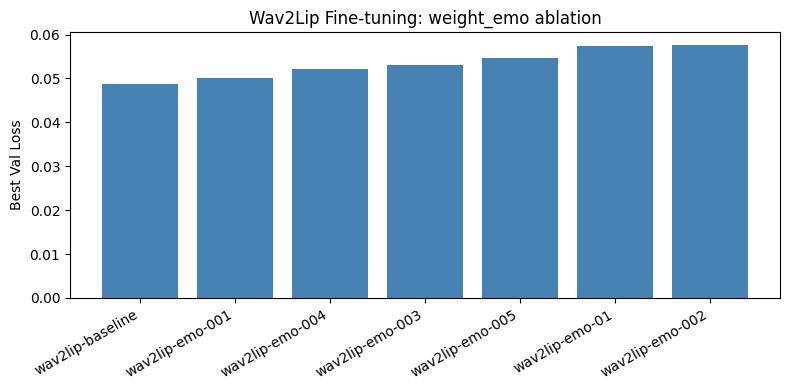

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(all_results)
best_recon = df["best_recon"].min()
recon_tol = 0.01 * best_recon

df["within_recon_band"] = df["best_recon"] <= (best_recon + recon_tol)
df["selection_score"] = df["best_f1"].where(df["within_recon_band"], -1.0)

df = df.sort_values(["selection_score", "best_recon", "best_f1", "best_total"], ascending=[False, True, False, True]).reset_index(drop=True)

print(
    "Selection rule: maximize F1 among models within 1% of best recon "
    f"(best recon={best_recon:.4f})."
)
print(df[[
    "name", "weight_emo", "best_recon", "best_emo_accuracy", "best_f1", "best_total", "within_recon_band"
]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df["name"], df["best_recon"], color="steelblue")
axes[0].set_ylabel("Best val recon")
axes[0].set_title("Reconstruction by weight_emo")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(df["name"], df["best_f1"], color="darkorange")
axes[1].set_ylabel("Best val F1")
axes[1].set_title("Emotion F1 by weight_emo")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [10]:
best_emo_df = df[df["weight_emo"] > 0]
if len(best_emo_df) > 0:
    best_name = best_emo_df.iloc[0]["name"]
    best_weight_emo = float(best_emo_df.iloc[0]["weight_emo"])
else:
    best_name = df.iloc[0]["name"]
    best_weight_emo = float(df.iloc[0]["weight_emo"])

def _load_state_dict(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

best_model = load_wav2lip(WAV2LIP_CKPT, DEVICE)
best_model.load_state_dict(_load_state_dict(OUT_DIR / best_name / "wav2lip.pth"))
best_model.eval()
audio_proj = nn.Linear(AUDIO_DIM, PROJ_DIM).to(DEVICE)
video_proj = nn.Linear(VIDEO_DIM, PROJ_DIM).to(DEVICE)
ap_path = OUT_DIR / best_name / "audio_proj.pth"
vp_path = OUT_DIR / best_name / "video_proj.pth"
if ap_path.is_file() and vp_path.is_file():
    audio_proj.load_state_dict(_load_state_dict(ap_path))
    video_proj.load_state_dict(_load_state_dict(vp_path))
else:
    print("Warning: projection checkpoints missing; emotion metrics may be wrong.")
print(f"Loaded best model: {best_name} (weight_emo={best_weight_emo})")

v_metrics = evaluate(best_model, val_loader, best_weight_emo, audio_proj, video_proj)
te_metrics = evaluate(best_model, test_loader, best_weight_emo, audio_proj, video_proj)

def _print_metrics(label, m):
    print(f"\n{label}:")
    print(f"  L1 recon:           {m['recon']:.4f}")
    print(f"  Emotion loss:       {m['emotion']:.4f}")
    print(f"  Total loss:         {m['total']:.4f}")
    print(f"  Emotion accuracy:   {m['emo_accuracy']:.4f}")
    print(f"  F1:                 {m['f1']:.4f}")
    print(f"  Mean cosine sim:    {m['mean_cosine_sim']:.4f}")
    prf = m["per_emotion_prf"]
    print("  Per-emotion P / R / F1:")
    for e in range(len(EMOTIONS)):
        print(f"    {EMOTIONS[e]:>8s}  P={prf[e]['precision']:.3f}  R={prf[e]['recall']:.3f}  F1={prf[e]['f1']:.3f}  n={prf[e]['support']}")

_print_metrics("Best model — validation", v_metrics)
_print_metrics("Best model — test (held-out)", te_metrics)

del best_model, audio_proj, video_proj
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Loaded best model: wav2lip-baseline (weight_emo=0.0)



Best model — validation:
  L1 recon:           0.0512
  Emotion loss:       0.0000
  Total loss:         0.0512
  Emotion accuracy:   0.7917
  F1:                 0.7947
  Mean cosine sim:    0.0000
  Per-emotion P / R / F1:
       happy  P=0.952  R=0.833  F1=0.889  n=24
       angry  P=0.704  R=0.792  F1=0.745  n=24
     disgust  P=0.750  R=0.750  F1=0.750  n=24

Best model — test (held-out):
  L1 recon:           0.0604
  Emotion loss:       0.0000
  Total loss:         0.0604
  Emotion accuracy:   0.9028
  F1:                 0.9032
  Mean cosine sim:    0.0000
  Per-emotion P / R / F1:
       happy  P=0.957  R=0.917  F1=0.936  n=24
       angry  P=0.821  R=0.958  F1=0.885  n=24
     disgust  P=0.952  R=0.833  F1=0.889  n=24


In [11]:
"""Baseline vs Best: comparison with statistical significance (p-values)"""
from scipy import stats
from sklearn.metrics import precision_recall_fscore_support, f1_score
import subprocess


# ── SyncNet (Wav2Lip lipsync expert) for LSE-C / LSE-D ──────────────

SYNCNET_CKPT = Path("/content/Wav2Lip/checkpoints/lipsync_expert.pth")
SYNCNET_URL = "https://huggingface.co/Nekochu/Wav2Lip/resolve/main/lipsync_expert.pth"
SYNCNET_T = 5


class _SyncNetConv(nn.Module):
    def __init__(self, cin, cout, kernel_size, stride, padding, residual=False):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(cin, cout, kernel_size, stride, padding),
            nn.BatchNorm2d(cout),
        )
        self.act = nn.ReLU()
        self.residual = residual

    def forward(self, x):
        out = self.conv_block(x)
        if self.residual:
            out += x
        return self.act(out)


class SyncNet_color(nn.Module):
    def __init__(self):
        super().__init__()
        self.face_encoder = nn.Sequential(
            _SyncNetConv(15, 32, (7, 7), 1, 3),
            _SyncNetConv(32, 64, 5, (1, 2), 1),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 128, 3, 2, 1),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 256, 3, 2, 1),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 512, 3, 2, 1),
            _SyncNetConv(512, 512, 3, 1, 1, residual=True),
            _SyncNetConv(512, 512, 3, 1, 1, residual=True),
            _SyncNetConv(512, 512, 3, 2, 1),
            _SyncNetConv(512, 512, 3, 1, 0),
            _SyncNetConv(512, 512, 1, 1, 0),
        )
        self.audio_encoder = nn.Sequential(
            _SyncNetConv(1, 32, 3, 1, 1),
            _SyncNetConv(32, 32, 3, 1, 1, residual=True),
            _SyncNetConv(32, 32, 3, 1, 1, residual=True),
            _SyncNetConv(32, 64, 3, (3, 1), 1),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 64, 3, 1, 1, residual=True),
            _SyncNetConv(64, 128, 3, 3, 1),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 128, 3, 1, 1, residual=True),
            _SyncNetConv(128, 256, 3, (3, 2), 1),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 256, 3, 1, 1, residual=True),
            _SyncNetConv(256, 512, 3, 1, 0),
            _SyncNetConv(512, 512, 1, 1, 0),
        )

    def forward(self, audio_sequences, face_sequences):
        face_embedding = self.face_encoder(face_sequences)
        audio_embedding = self.audio_encoder(audio_sequences)
        audio_embedding = audio_embedding.view(audio_embedding.size(0), -1)
        face_embedding = face_embedding.view(face_embedding.size(0), -1)
        audio_embedding = F.normalize(audio_embedding, p=2, dim=1)
        face_embedding = F.normalize(face_embedding, p=2, dim=1)
        return audio_embedding, face_embedding


def load_syncnet(ckpt_path, device):
    ckpt_path = Path(ckpt_path)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    def _load_ckpt(path):
        try:
            return torch.load(path, map_location=device, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=device)

    if not ckpt_path.exists():
        print(f"Downloading SyncNet checkpoint -> {ckpt_path}")
        subprocess.check_call(["wget", "-q", SYNCNET_URL, "-O", str(ckpt_path)])

    model = SyncNet_color()
    try:
        ckpt = _load_ckpt(ckpt_path)
        sd = ckpt.get("state_dict", ckpt)
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=True)
    except RuntimeError:
        print("SyncNet checkpoint mismatch. Re-downloading official lipsync_expert.pth...")
        subprocess.check_call(["wget", "-q", SYNCNET_URL, "-O", str(ckpt_path)])
        ckpt = _load_ckpt(ckpt_path)
        sd = ckpt.get("state_dict", ckpt)
        sd = {k.replace("module.", ""): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=True)

    model.to(device).eval()
    return model

baseline_name = df.loc[df["weight_emo"] == 0.0, "name"].iloc[0]
best_emo_df = df.loc[df["weight_emo"] > 0.0]
best_name = best_emo_df.iloc[0]["name"]
print(f"Baseline: {baseline_name}  |  Best emotion-aware: {best_name}")

def eval_model_per_sample(model, loader, syncnet=None):
    """Per-sample L1, correctness, F1, per-emotion P/R/F1, and LSE-C/D."""
    model.eval()
    sample_recons = []
    sample_correct = []
    all_labels = []
    all_preds = []
    correct_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    total_by_emo = {e: 0 for e in range(len(EMOTIONS))}
    lse_c_vals = []
    lse_d_vals = []
    with torch.no_grad():
        for batch in tqdm(loader, leave=False, desc="Eval"):
            mel = batch["mel"].to(DEVICE)
            face_in = batch["face_input"].to(DEVICE)
            gt = batch["gt"].to(DEVICE)
            B, T = mel.shape[0], mel.shape[1]
            all_gen = []
            per_sample_recon = torch.zeros(B, device=DEVICE)
            for t in range(T):
                gen = model(mel[:, t], face_in[:, t])
                all_gen.append(gen)
                per_sample_recon += F.l1_loss(gen, gt[:, t], reduction="none").mean(dim=(1, 2, 3))
            per_sample_recon /= T
            sample_recons.extend(per_sample_recon.cpu().tolist())

            gen_video = torch.stack(all_gen, dim=1)
            logits, enc_labels = classify_gen_video(gen_video, batch["emotion"])
            preds = logits.argmax(dim=1)
            hits = (preds == enc_labels).cpu().tolist()
            sample_correct.extend(hits)
            for i, e in enumerate(batch["emotion"].tolist()):
                p = int(preds[i].item())
                all_labels.append(e)
                all_preds.append(p)
                total_by_emo[e] += 1
                if hits[i]:
                    correct_by_emo[e] += 1

            if syncnet is not None and T >= SYNCNET_T:
                gen_stack = torch.stack(all_gen, dim=1)  # (B, T, 3, 96, 96)
                for b in range(B):
                    for t0 in range(T - SYNCNET_T + 1):
                        lips = gen_stack[b, t0:t0 + SYNCNET_T, :, 48:, :]  # (5, 3, 48, 96)
                        vid_in = lips.reshape(1, 15, 48, 96)
                        aud_in = mel[b, t0 + SYNCNET_T // 2].unsqueeze(0)  # (1, 1, 80, 16)
                        a_emb, v_emb = syncnet(aud_in, vid_in)
                        cs = F.cosine_similarity(a_emb, v_emb).item()
                        lse_c_vals.append(cs)
                        lse_d_vals.append(1.0 - cs)

    total_correct = sum(correct_by_emo.values())
    total_samples = sum(total_by_emo.values())

    per_emotion_prf = {}
    emo_f1 = 0.0
    if all_labels:
        prec, rec, f1, sup = precision_recall_fscore_support(
            all_labels, all_preds, labels=list(range(len(EMOTIONS))), zero_division=0,
        )
        emo_f1 = float(f1_score(all_labels, all_preds, labels=list(range(len(EMOTIONS))), average="macro", zero_division=0))
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": float(prec[e]), "recall": float(rec[e]), "f1": float(f1[e]), "support": int(sup[e])}
    else:
        for e in range(len(EMOTIONS)):
            per_emotion_prf[e] = {"precision": 0.0, "recall": 0.0, "f1": 0.0, "support": 0}

    return {
        "recon": np.mean(sample_recons),
        "recon_samples": np.array(sample_recons),
        "emo_accuracy": total_correct / total_samples if total_samples > 0 else 0,
        "f1": emo_f1,
        "correct": np.array(sample_correct, dtype=bool),
        "by_emotion": {
            e: correct_by_emo[e] / total_by_emo[e] if total_by_emo[e] > 0 else 0
            for e in range(len(EMOTIONS))
        },
        "per_emotion_prf": per_emotion_prf,
        "lse_c": float(np.mean(lse_c_vals)) if lse_c_vals else float("nan"),
        "lse_d": float(np.mean(lse_d_vals)) if lse_d_vals else float("nan"),
        "lse_c_samples": np.array(lse_c_vals, dtype=np.float64),
    }


def _load_state_dict(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)

baseline = load_wav2lip(WAV2LIP_CKPT, DEVICE)
baseline.load_state_dict(_load_state_dict(OUT_DIR / baseline_name / "wav2lip.pth"))

best = load_wav2lip(WAV2LIP_CKPT, DEVICE)
best.load_state_dict(_load_state_dict(OUT_DIR / best_name / "wav2lip.pth"))

try:
    syncnet = load_syncnet(SYNCNET_CKPT, DEVICE)
except Exception as exc:
    syncnet = None
    print(f"Warning: failed to load SyncNet ({exc}) — LSE-C/LSE-D will be NaN")

print("Evaluating baseline (L1 only)...")
baseline_metrics = eval_model_per_sample(baseline, val_loader, syncnet=syncnet)
print("Evaluating best (L1 + emotion loss)...")
best_metrics = eval_model_per_sample(best, val_loader, syncnet=syncnet)

# --- Statistical significance ---
# L1 reconstruction: paired t-test & Wilcoxon signed-rank
_br = baseline_metrics["recon_samples"]
_bst = best_metrics["recon_samples"]
_n = min(len(_br), len(_bst))
_br, _bst = _br[:_n], _bst[:_n]
if _n < 2:
    t_stat, p_ttest = float("nan"), float("nan")
    w_stat, p_wilcox = float("nan"), float("nan")
else:
    t_stat, p_ttest = stats.ttest_rel(_br, _bst)
    try:
        w_stat, p_wilcox = stats.wilcoxon(_br, _bst)
    except ValueError:
        w_stat, p_wilcox = float("nan"), float("nan")

# Emotion accuracy: McNemar's test on paired correct/incorrect (same prefix length as L1)
b_ok = baseline_metrics["correct"][:_n]
e_ok = best_metrics["correct"][:_n]
n01 = int((b_ok & ~e_ok).sum())  # baseline correct, best wrong
n10 = int((~b_ok & e_ok).sum())  # baseline wrong, best correct
mcnemar_chi2 = (abs(n01 - n10) - 1) ** 2 / max(n01 + n10, 1)
p_mcnemar = 1 - stats.chi2.cdf(mcnemar_chi2, df=1) if (n01 + n10) > 0 else 1.0

# LSE-C: paired t-test on per-window cosine similarities
_lse_b = baseline_metrics["lse_c_samples"]
_lse_e = best_metrics["lse_c_samples"]
_lse_n = min(len(_lse_b), len(_lse_e))
if _lse_n >= 2:
    t_lse, p_lse = stats.ttest_rel(_lse_b[:_lse_n], _lse_e[:_lse_n])
else:
    t_lse, p_lse = float("nan"), float("nan")

# ΔF1 and ΔLSE-C
delta_f1 = best_metrics["f1"] - baseline_metrics["f1"]
delta_lse_c = best_metrics["lse_c"] - baseline_metrics["lse_c"]
delta_lse_c_pct = (delta_lse_c / abs(baseline_metrics["lse_c"]) * 100) if baseline_metrics["lse_c"] != 0 and not np.isnan(baseline_metrics["lse_c"]) else float("nan")

print("\n=== Statistical significance ===")
print(f"L1 recon  — paired t-test: t={t_stat:.4f}, p={p_ttest:.4e}")
print(f"L1 recon  — Wilcoxon signed-rank: W={w_stat:.1f}, p={p_wilcox:.4e}")
print(f"Emo acc   — McNemar's test: χ²={mcnemar_chi2:.4f}, p={p_mcnemar:.4e}"
      f"  (n01={n01}, n10={n10})")
print(f"LSE-C     — paired t-test: t={t_lse:.4f}, p={p_lse:.4e}")

# --- Success criteria ---
f1_pass = delta_f1 >= 0.10 and p_mcnemar < 0.05
lse_pass = np.isnan(delta_lse_c_pct) or (abs(delta_lse_c_pct) <= 2.0)
lse_sig = (not np.isnan(p_lse)) and p_lse < 0.05

print("\n=== Success criteria ===")
print(f"  ΔF1 = {delta_f1:+.4f} (≥ +0.10 required)   McNemar p = {p_mcnemar:.4e} (< 0.05 required)  → {'PASS' if f1_pass else 'FAIL'}")
print(f"  ΔLSE-C = {delta_lse_c_pct:+.2f}% (≤ ±2% required)  paired t p = {p_lse:.4e} (< 0.05 required)  → {'PASS' if lse_pass else 'FAIL'}")
if lse_sig and not lse_pass:
    print("    LSE-C degradation is statistically significant — lip sync quality affected")
elif not lse_sig and not lse_pass:
    print("    LSE-C change exceeds 2% but is not statistically significant")

# --- Summary table ---
cmp = pd.DataFrame({
    "metric": ["L1 recon", "emo_accuracy", "F1", "LSE-C ↑", "LSE-D ↓"],
    baseline_name: [
        baseline_metrics["recon"], baseline_metrics["emo_accuracy"],
        baseline_metrics["f1"], baseline_metrics["lse_c"], baseline_metrics["lse_d"],
    ],
    best_name: [
        best_metrics["recon"], best_metrics["emo_accuracy"],
        best_metrics["f1"], best_metrics["lse_c"], best_metrics["lse_d"],
    ],
    "p-value": [p_wilcox, p_mcnemar, p_mcnemar, p_lse, p_lse],
})
cmp["delta"] = cmp[best_name] - cmp[baseline_name]
print("\n=== Baseline vs Best comparison ===")
print(cmp.to_string(index=False))

per_emo_rows = []
for e in range(len(EMOTIONS)):
    bp = baseline_metrics["per_emotion_prf"][e]
    ep = best_metrics["per_emotion_prf"][e]
    per_emo_rows.append({
        "emotion": EMOTIONS[e],
        f"{baseline_name}_P": bp["precision"],
        f"{baseline_name}_R": bp["recall"],
        f"{baseline_name}_F1": bp["f1"],
        f"{best_name}_P": ep["precision"],
        f"{best_name}_R": ep["recall"],
        f"{best_name}_F1": ep["f1"],
        "delta_F1": ep["f1"] - bp["f1"],
    })
per_emo = pd.DataFrame(per_emo_rows)
print("\n=== Per-emotion precision / recall / F1 ===")
print(per_emo.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x_agg = np.arange(3)
w_agg = 0.35
axes[0].bar(
    x_agg - w_agg / 2,
    [baseline_metrics["recon"], baseline_metrics["emo_accuracy"], baseline_metrics["f1"]],
    w_agg, label=baseline_name, color="gray", alpha=0.7,
)
axes[0].bar(
    x_agg + w_agg / 2,
    [best_metrics["recon"], best_metrics["emo_accuracy"], best_metrics["f1"]],
    w_agg, label=best_name, color="steelblue", alpha=0.7,
)
axes[0].set_xticks(x_agg)
axes[0].set_xticklabels(["L1 recon", "accuracy", "F1"])
axes[0].set_ylabel("Value")
axes[0].legend()
axes[0].set_title("Aggregate metrics (val)")

x = np.arange(len(EMOTIONS))
w = 0.35
axes[1].bar(x - w / 2, per_emo[f"{baseline_name}_F1"], w, label=baseline_name, color="gray", alpha=0.7)
axes[1].bar(x + w / 2, per_emo[f"{best_name}_F1"], w, label=best_name, color="steelblue", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(EMOTIONS)
axes[1].set_ylabel("F1")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].set_title("Per-emotion F1 (val)")

bar_width = 0.15
x_pr = np.arange(len(EMOTIONS))
for offset, (col, lbl) in enumerate([
    (f"{baseline_name}_P", "base P"), (f"{baseline_name}_R", "base R"),
    (f"{best_name}_P", "best P"), (f"{best_name}_R", "best R"),
]):
    axes[2].bar(x_pr + (offset - 1.5) * bar_width, per_emo[col], bar_width, label=lbl, alpha=0.75)
axes[2].set_xticks(x_pr)
axes[2].set_xticklabels(EMOTIONS)
axes[2].set_ylabel("Score")
axes[2].set_ylim(0, 1.05)
axes[2].legend(fontsize=7, ncol=2)
axes[2].set_title("Per-emotion P / R (val)")

plt.tight_layout()
plt.show()

print("\n=== Side-by-side sample frames (one per emotion) ===")
best.eval()
one_per_emotion = {}
for batch in val_loader:
    for i in range(batch["emotion"].shape[0]):
        e = batch["emotion"][i].item()
        if e not in one_per_emotion:
            one_per_emotion[e] = {}
            for k, v in batch.items():
                if torch.is_tensor(v):
                    one_per_emotion[e][k] = v[i]
                elif isinstance(v, list):
                    one_per_emotion[e][k] = v[i]
                else:
                    one_per_emotion[e][k] = v
    if len(one_per_emotion) == len(EMOTIONS):
        break

fig, axes = plt.subplots(len(EMOTIONS), 4, figsize=(10, 2.5 * len(EMOTIONS)))
for row, e in enumerate(range(len(EMOTIONS))):
    if e not in one_per_emotion:
        continue
    sample = one_per_emotion[e]
    mel = sample["mel"].unsqueeze(0).to(DEVICE)
    face_in = sample["face_input"].unsqueeze(0).to(DEVICE)
    gt = sample["gt"].unsqueeze(0).to(DEVICE)
    T = mel.shape[1]
    with torch.no_grad():
        base_gen = [baseline(mel[:, t], face_in[:, t]) for t in range(T)]
        best_gen = [best(mel[:, t], face_in[:, t]) for t in range(T)]
    mid = T // 2
    axes[row, 0].imshow(gt[0, mid].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 0].set_title(f"{EMOTIONS[e]} (GT)")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(base_gen[mid][0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 1].set_title("baseline")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(best_gen[mid][0].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[row, 2].set_title("best (emo)")
    axes[row, 2].axis("off")
    diff = (best_gen[mid][0] - base_gen[mid][0]).abs().mean(dim=0).cpu()
    axes[row, 3].imshow(diff, cmap="hot")
    axes[row, 3].set_title("|diff|")
    axes[row, 3].axis("off")
plt.suptitle("Baseline vs emotion-aware: sample frame per emotion")
plt.tight_layout()
plt.show()

del baseline, best
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Baseline: wav2lip-baseline  |  Best emotion-aware: wav2lip-emo-001


RuntimeError: Error(s) in loading state_dict for SyncNet_color:
	Unexpected key(s) in state_dict: "face_encoder.14.conv_block.0.weight", "face_encoder.14.conv_block.0.bias", "face_encoder.14.conv_block.1.weight", "face_encoder.14.conv_block.1.bias", "face_encoder.14.conv_block.1.running_mean", "face_encoder.14.conv_block.1.running_var", "face_encoder.14.conv_block.1.num_batches_tracked", "face_encoder.15.conv_block.0.weight", "face_encoder.15.conv_block.0.bias", "face_encoder.15.conv_block.1.weight", "face_encoder.15.conv_block.1.bias", "face_encoder.15.conv_block.1.running_mean", "face_encoder.15.conv_block.1.running_var", "face_encoder.15.conv_block.1.num_batches_tracked", "face_encoder.16.conv_block.0.weight", "face_encoder.16.conv_block.0.bias", "face_encoder.16.conv_block.1.weight", "face_encoder.16.conv_block.1.bias", "face_encoder.16.conv_block.1.running_mean", "face_encoder.16.conv_block.1.running_var", "face_encoder.16.conv_block.1.num_batches_tracked", "audio_encoder.13.conv_